<a href="https://colab.research.google.com/github/adiptad09/iim_epba_group_6_capstone_project/blob/epba14/Understanding_Workplace_Issues_in_a_Changing_World_Group_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving text.xlsx to text (5).xlsx
(10335, 3)
['text', 'label', 'original_text']
                                                text     label  \
0  Ã°Å¸â€™Â¯ i work in tech. The is true. ItÃ¢â‚¬...  Negative   
1    Same case with non matured managers everywhere.   Neutral   
2                Are mera manager reddit pe kab aya?   Neutral   
3  OP also sounds rather young and seems to be un...   Neutral   
4  Not always. Some projects at TCS are way more ...  Positive   

                                       original_text  
0  Ã°Å¸â€™Â¯ i work in tech. The is true. ItÃ¢â‚¬...  
1    Same case with non matured managers everywhere.  
2                Are mera manager reddit pe kab aya?  
3  OP also sounds rather young and seems to be un...  
4  Not always. Some projects at TCS are way more ...  
Labeled rows: 1767
Unlabeled rows: 8568
label
Neutral     936
Positive    553
Negative    278
Name: count, dtype: int64
Train: (1236, 4)
Validation: (265, 4)
Test: (266, 4)
TF-IDF shapes: (1236

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Embedding shapes: (1236, 384) (265, 384) (266, 384)

MULTILINGUAL CLASSIFIER - VALIDATION
Accuracy     : 0.6226
Macro F1     : 0.5894
Weighted F1  : 0.6312
              precision    recall  f1-score   support

    Positive       0.60      0.61      0.61        83
    Negative       0.39      0.57      0.47        42
     Neutral       0.76      0.64      0.69       140

    accuracy                           0.62       265
   macro avg       0.58      0.61      0.59       265
weighted avg       0.65      0.62      0.63       265


SVM - VALIDATION
Accuracy     : 0.7472
Macro F1     : 0.656
Weighted F1  : 0.7281
              precision    recall  f1-score   support

    Positive       0.72      0.76      0.74        83
    Negative       0.75      0.29      0.41        42
     Neutral       0.76      0.88      0.82       140

    accuracy                           0.75       265
   macro avg       0.74      0.64      0.66       265
weighted avg       0.75      0.75      0.73       265


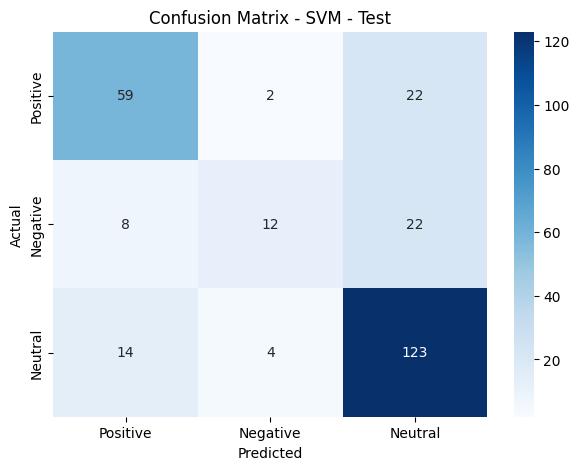

Saved: best_model_sentiment_predictions.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =========================================================
# MODEL COMPARISON: MULTILINGUAL vs SVM vs NAIVE BAYES
# Classes: Positive / Negative / Neutral
# =========================================================

# !pip -q install pandas numpy scikit-learn openpyxl matplotlib seaborn scipy sentence-transformers

# =========================================================
# 1) IMPORTS
# =========================================================
import re
import unicodedata
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from scipy.sparse import hstack

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from sentence_transformers import SentenceTransformer

# =========================================================
# 2) UPLOAD FILE
# =========================================================
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)
df.columns = [c.strip().lower() for c in df.columns]

df["original_text"] = df["text"].astype(str)

print(df.shape)
print(df.columns.tolist())
print(df.head())

# =========================================================
# 3) CLEAN TEXT
# =========================================================
def clean_text(x):
    if pd.isna(x):
        return ""
    x = str(x)
    x = unicodedata.normalize("NFKC", x)

    replacements = {
        "â€™": "'",
        "â€˜": "'",
        "â€œ": '"',
        "â€": '"',
        "â€“": "-",
        "â€”": "-",
        "…": "...",
        "\xa0": " ",
        "Ã¢â‚¬â„¢": "'",
        "Ã¢â‚¬Å“": '"',
        "Ã¢â‚¬Â": '"'
    }
    for k, v in replacements.items():
        x = x.replace(k, v)

    x = x.lower().strip()
    x = re.sub(r"http\S+|www\S+", " ", x)
    x = re.sub(r"<.*?>", " ", x)
    x = re.sub(r"@\w+", " ", x)
    x = re.sub(r"#", "", x)
    x = re.sub(r"\d+", " ", x)
    x = re.sub(r"[^\w\s']", " ", x)
    x = re.sub(r"(.)\1{3,}", r"\1\1", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

assert "text" in df.columns, "Column 'text' not found."
assert "label" in df.columns, "Column 'label' not found."

df["text"] = df["text"].astype(str).apply(clean_text)
df["label"] = df["label"].astype(str).str.strip().str.title()
df["label"] = df["label"].replace({
    "Nan": np.nan,
    "": np.nan,
    "Pos": "Positive",
    "Neg": "Negative",
    "Neu": "Neutral"
})

allowed_labels = ["Positive", "Negative", "Neutral"]

labeled_df = df[df["label"].isin(allowed_labels)].copy()
unlabeled_df = df[~df["label"].isin(allowed_labels)].copy()

print("Labeled rows:", labeled_df.shape[0])
print("Unlabeled rows:", unlabeled_df.shape[0])
print(labeled_df["label"].value_counts())

# =========================================================
# 4) LABEL ENCODING
# =========================================================
label2id = {label: i for i, label in enumerate(allowed_labels)}
id2label = {i: label for label, i in label2id.items()}
labeled_df["target"] = labeled_df["label"].map(label2id)

# =========================================================
# 5) TRAIN / VALIDATION / TEST SPLIT
# =========================================================
train_df, temp_df = train_test_split(
    labeled_df,
    test_size=0.30,
    stratify=labeled_df["target"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["target"],
    random_state=42
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

y_train = train_df["target"].values
y_val = val_df["target"].values
y_test = test_df["target"].values

# =========================================================
# 6) TF-IDF FEATURES FOR SVM + NB
# =========================================================
word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    max_features=40000,
    sublinear_tf=True,
    strip_accents="unicode"
)

char_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=3,
    max_df=0.95,
    max_features=40000,
    sublinear_tf=True,
    strip_accents="unicode"
)

X_train_word = word_vectorizer.fit_transform(train_df["text"])
X_val_word   = word_vectorizer.transform(val_df["text"])
X_test_word  = word_vectorizer.transform(test_df["text"])

X_train_char = char_vectorizer.fit_transform(train_df["text"])
X_val_char   = char_vectorizer.transform(val_df["text"])
X_test_char  = char_vectorizer.transform(test_df["text"])

X_train_tfidf = hstack([X_train_word, X_train_char]).tocsr()
X_val_tfidf   = hstack([X_val_word, X_val_char]).tocsr()
X_test_tfidf  = hstack([X_test_word, X_test_char]).tocsr()

print("TF-IDF shapes:", X_train_tfidf.shape, X_val_tfidf.shape, X_test_tfidf.shape)

# =========================================================
# 7) MULTILINGUAL EMBEDDINGS
# =========================================================
embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

X_train_emb = embedder.encode(train_df["text"].tolist(), batch_size=64, show_progress_bar=True)
X_val_emb   = embedder.encode(val_df["text"].tolist(), batch_size=64, show_progress_bar=True)
X_test_emb  = embedder.encode(test_df["text"].tolist(), batch_size=64, show_progress_bar=True)

print("Embedding shapes:", X_train_emb.shape, X_val_emb.shape, X_test_emb.shape)

# =========================================================
# 8) TRAIN MODELS
# =========================================================
# Model 1: Multilingual classifier
multi_model = LogisticRegression(
    C=1.0,
    class_weight="balanced",
    max_iter=5000,
    solver="lbfgs",
    multi_class="multinomial",
    random_state=42
)
multi_model.fit(X_train_emb, y_train)

# Model 2: SVM
svm_model = LinearSVC(
    C=0.25,
    class_weight="balanced",
    random_state=42
)
svm_model.fit(X_train_tfidf, y_train)

# Model 3: Naive Bayes
nb_model = ComplementNB(alpha=0.5)
nb_model.fit(X_train_tfidf, y_train)

# =========================================================
# 9) EVALUATION FUNCTION
# =========================================================
def evaluate_model(name, model, X, y_true):
    y_pred = model.predict(X)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    print(f"\n{name}")
    print("Accuracy     :", round(acc, 4))
    print("Macro F1     :", round(macro_f1, 4))
    print("Weighted F1  :", round(weighted_f1, 4))
    print(classification_report(y_true, y_pred, target_names=allowed_labels))

    return y_pred, acc, macro_f1, weighted_f1

# =========================================================
# 10) VALIDATION RESULTS
# =========================================================
multi_val_pred, multi_val_acc, multi_val_macro, multi_val_weighted = evaluate_model(
    "MULTILINGUAL CLASSIFIER - VALIDATION", multi_model, X_val_emb, y_val
)

svm_val_pred, svm_val_acc, svm_val_macro, svm_val_weighted = evaluate_model(
    "SVM - VALIDATION", svm_model, X_val_tfidf, y_val
)

nb_val_pred, nb_val_acc, nb_val_macro, nb_val_weighted = evaluate_model(
    "NAIVE BAYES - VALIDATION", nb_model, X_val_tfidf, y_val
)

# =========================================================
# 11) TEST RESULTS
# =========================================================
multi_test_pred, multi_test_acc, multi_test_macro, multi_test_weighted = evaluate_model(
    "MULTILINGUAL CLASSIFIER - TEST", multi_model, X_test_emb, y_test
)

svm_test_pred, svm_test_acc, svm_test_macro, svm_test_weighted = evaluate_model(
    "SVM - TEST", svm_model, X_test_tfidf, y_test
)

nb_test_pred, nb_test_acc, nb_test_macro, nb_test_weighted = evaluate_model(
    "NAIVE BAYES - TEST", nb_model, X_test_tfidf, y_test
)

# =========================================================
# 12) SELECT BEST MODEL
# Combined score using validation:
# 40% weighted F1 + 35% accuracy + 25% macro F1
# =========================================================
results_df = pd.DataFrame({
    "Model": ["Multilingual_Classifier", "SVM", "Naive_Bayes"],
    "Val_Accuracy": [multi_val_acc, svm_val_acc, nb_val_acc],
    "Val_Macro_F1": [multi_val_macro, svm_val_macro, nb_val_macro],
    "Val_Weighted_F1": [multi_val_weighted, svm_val_weighted, nb_val_weighted],
    "Test_Accuracy": [multi_test_acc, svm_test_acc, nb_test_acc],
    "Test_Macro_F1": [multi_test_macro, svm_test_macro, nb_test_macro],
    "Test_Weighted_F1": [multi_test_weighted, svm_test_weighted, nb_test_weighted],
})

results_df["Selection_Score"] = (
    0.40 * results_df["Val_Weighted_F1"] +
    0.35 * results_df["Val_Accuracy"] +
    0.25 * results_df["Val_Macro_F1"]
)

results_df = results_df.sort_values("Selection_Score", ascending=False).reset_index(drop=True)
print(results_df)

best_model_name = results_df.loc[0, "Model"]
print("\nBest model selected:", best_model_name)

# =========================================================
# 13) CONFUSION MATRIX FOR BEST MODEL ON TEST
# =========================================================
if best_model_name == "Multilingual_Classifier":
    best_test_pred = multi_test_pred
elif best_model_name == "SVM":
    best_test_pred = svm_test_pred
else:
    best_test_pred = nb_test_pred

cm = confusion_matrix(y_test, best_test_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=allowed_labels,
    yticklabels=allowed_labels
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name} - Test")
plt.show()

# =========================================================
# 14) RETRAIN BEST MODEL ON ALL LABELED DATA
# =========================================================
if best_model_name == "Multilingual_Classifier":
    X_all = embedder.encode(labeled_df["text"].tolist(), batch_size=64, show_progress_bar=True)
    X_unl = embedder.encode(unlabeled_df["text"].tolist(), batch_size=64, show_progress_bar=True) if len(unlabeled_df) > 0 else None

    final_model = LogisticRegression(
        C=1.0,
        class_weight="balanced",
        max_iter=5000,
        solver="lbfgs",
        multi_class="multinomial",
        random_state=42
    )
    final_model.fit(X_all, labeled_df["target"].values)

    labeled_pred = final_model.predict(X_all)
    labeled_prob = final_model.predict_proba(X_all)

    if len(unlabeled_df) > 0:
        unlabeled_pred = final_model.predict(X_unl)
        unlabeled_prob = final_model.predict_proba(X_unl)

elif best_model_name == "SVM":
    X_all_word = word_vectorizer.fit_transform(labeled_df["text"])
    X_all_char = char_vectorizer.fit_transform(labeled_df["text"])
    X_all = hstack([X_all_word, X_all_char]).tocsr()

    final_model = LinearSVC(
        C=0.25,
        class_weight="balanced",
        random_state=42
    )
    final_model.fit(X_all, labeled_df["target"].values)

    labeled_pred = final_model.predict(X_all)

    # pseudo-probability-like scores from decision function
    labeled_scores = final_model.decision_function(X_all)
    if labeled_scores.ndim == 1:
        labeled_scores = np.column_stack([-labeled_scores, labeled_scores, np.zeros_like(labeled_scores)])

    def softmax_np(x):
        x = x - np.max(x, axis=1, keepdims=True)
        ex = np.exp(x)
        return ex / np.sum(ex, axis=1, keepdims=True)

    labeled_prob = softmax_np(labeled_scores)

    if len(unlabeled_df) > 0:
        X_unl_word = word_vectorizer.transform(unlabeled_df["text"])
        X_unl_char = char_vectorizer.transform(unlabeled_df["text"])
        X_unl = hstack([X_unl_word, X_unl_char]).tocsr()

        unlabeled_pred = final_model.predict(X_unl)
        unlabeled_scores = final_model.decision_function(X_unl)
        if unlabeled_scores.ndim == 1:
            unlabeled_scores = np.column_stack([-unlabeled_scores, unlabeled_scores, np.zeros_like(unlabeled_scores)])
        unlabeled_prob = softmax_np(unlabeled_scores)

else:
    X_all_word = word_vectorizer.fit_transform(labeled_df["text"])
    X_all_char = char_vectorizer.fit_transform(labeled_df["text"])
    X_all = hstack([X_all_word, X_all_char]).tocsr()

    final_model = ComplementNB(alpha=0.5)
    final_model.fit(X_all, labeled_df["target"].values)

    labeled_pred = final_model.predict(X_all)
    labeled_prob = final_model.predict_proba(X_all)

    if len(unlabeled_df) > 0:
        X_unl_word = word_vectorizer.transform(unlabeled_df["text"])
        X_unl_char = char_vectorizer.transform(unlabeled_df["text"])
        X_unl = hstack([X_unl_word, X_unl_char]).tocsr()

        unlabeled_pred = final_model.predict(X_unl)
        unlabeled_prob = final_model.predict_proba(X_unl)

# =========================================================
# 15) CONTINUOUS SENTIMENT SCORE
# Positive = +1, Negative = -1, Neutral = 0
# =========================================================
score_weights = np.array([
    1.0 if lbl == "Positive" else -1.0 if lbl == "Negative" else 0.0
    for lbl in allowed_labels
])

labeled_df["predicted_label"] = [id2label[i] for i in labeled_pred]
labeled_df["confidence"] = labeled_prob.max(axis=1)
labeled_df["sentiment_score"] = labeled_prob.dot(score_weights)

for i, label in enumerate(allowed_labels):
    labeled_df[f"prob_{label.lower()}"] = labeled_prob[:, i]

if len(unlabeled_df) > 0:
    unlabeled_df["predicted_label"] = [id2label[i] for i in unlabeled_pred]
    unlabeled_df["confidence"] = unlabeled_prob.max(axis=1)
    unlabeled_df["sentiment_score"] = unlabeled_prob.dot(score_weights)

    for i, label in enumerate(allowed_labels):
        unlabeled_df[f"prob_{label.lower()}"] = unlabeled_prob[:, i]

# =========================================================
# 16) EXPORT FINAL OUTPUT
# =========================================================
if len(unlabeled_df) > 0:
    final_output = pd.concat([labeled_df, unlabeled_df], axis=0).sort_index()
else:
    final_output = labeled_df.copy()

final_output["final_label"] = final_output["label"]
final_output.loc[final_output["final_label"].isna(), "final_label"] = final_output["predicted_label"]

preferred_order = [
    "original_text",
    "text",
    "label",
    "predicted_label",
    "final_label",
    "confidence",
    "sentiment_score"
]

existing_first = [c for c in preferred_order if c in final_output.columns]
remaining_cols = [c for c in final_output.columns if c not in existing_first]
final_output = final_output[existing_first + remaining_cols]

output_file = "best_model_sentiment_predictions.xlsx"
final_output.to_excel(output_file, index=False)

print("Saved:", output_file)
files.download(output_file)

# =========================================================
# 17) EXPORT MODEL COMPARISON
# =========================================================
comparison_file = "model_comparison_metrics.xlsx"
results_df.to_excel(comparison_file, index=False)
files.download(comparison_file)

Saving text.xlsx to text (7).xlsx
Shape: (10335, 3)
Columns: ['text', 'label', 'original_text']
                                                text     label  \
0  Ã°Å¸â€™Â¯ i work in tech. The is true. ItÃ¢â‚¬...  Negative   
1    Same case with non matured managers everywhere.   Neutral   
2                Are mera manager reddit pe kab aya?   Neutral   
3  OP also sounds rather young and seems to be un...   Neutral   
4  Not always. Some projects at TCS are way more ...  Positive   

                                       original_text  
0  Ã°Å¸â€™Â¯ i work in tech. The is true. ItÃ¢â‚¬...  
1    Same case with non matured managers everywhere.  
2                Are mera manager reddit pe kab aya?  
3  OP also sounds rather young and seems to be un...  
4  Not always. Some projects at TCS are way more ...  

Rows used for topic modeling: 10303
                                       original_text  \
0  Ã°Å¸â€™Â¯ i work in tech. The is true. ItÃ¢â‚¬...   
1    Same case with non matu

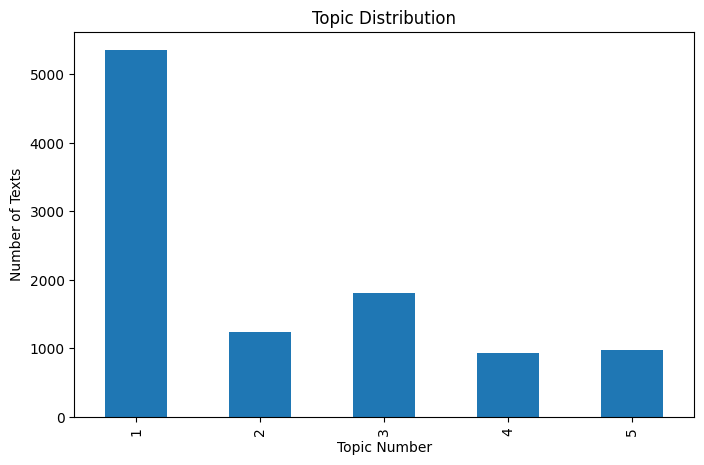


========== Topic 1 ==========
1. Iâ€™m 17, from India, and I took science after 10th because it felt like the only option. Everyone said it was the â€œright pathâ€ â€“ my parents, teachers, relativesâ€¦ but now I just feel trapped. I canâ€™t keep up with it. I donâ€™t understand chemistry at all, and I have my pre-board tomorrow. 
2. Please donâ€™t take me wrong but I have seen so many ethical issues in people when it comes to work. I have people working from home and some how I can tell you I can trust few of them as I can clearly tell they are ditching work when they can. I am not going too hard on them as they can loose their
3. Right like I get not giving yourself up for your job, but thereâ€™s a surprising amount of people who are like â€œugh why would I ever want to be friends with my coworkersâ€ and itâ€™s like donâ€™t you want to like the people you work with every day??
4. WFH is sustainable way of working. Today you are working in Bengaluru tomorrow you might work in Hyder

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =========================================================
# SINGLE CODE: TOPIC MODELING ONLY
# Ignores mojibake and special characters
# Uses cleaned topic text + NMF
# Exports:
#   1) topic_top_features_cleaned.xlsx
#   2) topic_assignment_cleaned.xlsx
# =========================================================

# !pip -q install pandas numpy scikit-learn openpyxl matplotlib

import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer

# ---------------------------------------------------------
# 1) Upload file
# Expected columns: text, label (label optional for topic modeling)
# ---------------------------------------------------------
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)
df.columns = [c.strip().lower() for c in df.columns]

assert "text" in df.columns, "Column 'text' not found."

df["original_text"] = df["text"].astype(str)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

# ---------------------------------------------------------
# 2) Clean text for topic modeling
# Removes mojibake, emojis, special chars, digits, URLs etc.
# Keeps only alphabetic words and spaces
# ---------------------------------------------------------
def clean_topic_text(x):
    if pd.isna(x):
        return ""

    x = str(x)
    x = unicodedata.normalize("NFKC", x)

    replacements = {
        "â€™": " ",
        "â€˜": " ",
        "â€œ": " ",
        "â€": " ",
        "â€“": " ",
        "â€”": " ",
        "…": " ",
        "\xa0": " ",
        "Ã¢â‚¬â„¢": " ",
        "Ã¢â‚¬Å“": " ",
        "Ã¢â‚¬Â": " ",
        "Ã°Å¸â€™Â¯": " ",
        "ðÿ": " ",
        "â": " ",
        "Ã": " "
    }

    for k, v in replacements.items():
        x = x.replace(k, v)

    x = x.lower().strip()

    # Remove URLs, HTML, mentions, hashtags
    x = re.sub(r"http\S+|www\S+", " ", x)
    x = re.sub(r"<.*?>", " ", x)
    x = re.sub(r"@\w+", " ", x)
    x = re.sub(r"#", " ", x)

    # Remove digits
    x = re.sub(r"\d+", " ", x)

    # Keep only letters and spaces
    x = re.sub(r"[^a-zA-Z\s]", " ", x)

    # Reduce repeated letters
    x = re.sub(r"(.)\1{3,}", r"\1\1", x)

    # Normalize spaces
    x = re.sub(r"\s+", " ", x).strip()

    return x

df["topic_text"] = df["text"].astype(str).apply(clean_topic_text)

# Remove blank rows for topic modeling
topic_df = df[df["topic_text"].str.strip() != ""].copy().reset_index(drop=True)

print("\nRows used for topic modeling:", topic_df.shape[0])
print(topic_df[["original_text", "topic_text"]].head())

# ---------------------------------------------------------
# 3) TF-IDF matrix for topic modeling
# ---------------------------------------------------------
topic_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.90,
    stop_words="english",
    strip_accents="unicode"
)

X_topic = topic_vectorizer.fit_transform(topic_df["topic_text"])
print("\nTopic matrix shape:", X_topic.shape)

# ---------------------------------------------------------
# 4) Fit NMF topic model
# Change n_topics if needed
# ---------------------------------------------------------
n_topics = 5

nmf_model = NMF(
    n_components=n_topics,
    random_state=42,
    init="nndsvda",
    max_iter=400
)

W = nmf_model.fit_transform(X_topic)   # document-topic strengths
H = nmf_model.components_              # topic-term weights

# ---------------------------------------------------------
# 5) Show top features / top words for each topic
# ---------------------------------------------------------
feature_names = topic_vectorizer.get_feature_names_out()

topic_summary = []

print("\n================ TOP FEATURES BY TOPIC ================\n")
for topic_idx, topic in enumerate(H):
    top_idx = topic.argsort()[:-16:-1]   # top 15 features
    top_terms = [feature_names[i] for i in top_idx]

    print(f"Topic {topic_idx + 1}:")
    print(", ".join(top_terms))
    print()

    topic_summary.append({
        "Topic": topic_idx + 1,
        "Top_Features": ", ".join(top_terms)
    })

topic_summary_df = pd.DataFrame(topic_summary)

# ---------------------------------------------------------
# 6) Assign dominant topic to each row
# ---------------------------------------------------------
topic_df["dominant_topic"] = np.argmax(W, axis=1) + 1
topic_df["topic_strength"] = np.max(W, axis=1)

print(topic_df[["original_text", "topic_text", "dominant_topic", "topic_strength"]].head())

# ---------------------------------------------------------
# 7) Plot topic distribution
# ---------------------------------------------------------
topic_counts = topic_df["dominant_topic"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
topic_counts.plot(kind="bar")
plt.xlabel("Topic Number")
plt.ylabel("Number of Texts")
plt.title("Topic Distribution")
plt.show()

# ---------------------------------------------------------
# 8) Show sample texts for each topic
# ---------------------------------------------------------
for t in sorted(topic_df["dominant_topic"].unique()):
    print(f"\n========== Topic {t} ==========")
    sample_rows = topic_df[topic_df["dominant_topic"] == t].sort_values(
        "topic_strength", ascending=False
    ).head(5)

    for i, txt in enumerate(sample_rows["original_text"].tolist(), 1):
        print(f"{i}. {txt[:300]}")

# ---------------------------------------------------------
# 9) Export outputs
# ---------------------------------------------------------
topic_summary_file = "topic_top_features_cleaned.xlsx"
topic_assignment_file = "topic_assignment_cleaned.xlsx"

topic_summary_df.to_excel(topic_summary_file, index=False)
topic_df.to_excel(topic_assignment_file, index=False)

print("\nSaved files:")
print(topic_summary_file)
print(topic_assignment_file)

files.download(topic_summary_file)
files.download(topic_assignment_file)